# Exploring Agent-Assisted Qualitative Analysis

**A learning notebook walking through Shreya Shankar's May 21, 2026 blog post.**

Source: Shreya Shankar — *Exploring Agent-Assisted Qualitative Analysis* (blog post, May 21, 2026)

This notebook restates the post's core ideas in a study-friendly form. Where helpful, I add small Python demonstrations on a tiny synthetic example *of the workflow itself* (not of the post's data — the actual tweet corpus is not redistributed here). The point of the code is to make the *mechanics* of coding / clustering concrete, not to reproduce her findings.

> "Agents can do the mechanical parts of qualitative analysis fast, but they have no taste." — Shreya Shankar

## Table of contents

1. Background: what qualitative analysis is
2. Grounded theory: open / axial / selective coding + memos
3. Why this is a hard problem for AI
4. The experimental setup (6 conditions, 451 tweets)
5. Findings — what agents got wrong
6. Findings — what it felt like to be the human in the loop
7. Looking forward
8. Mini Python demo: code reuse vs. one-off codes
9. Data sources

## 1. Background: what is qualitative analysis?

**Qualitative analysis** = reading a lot of messy unstructured data and trying to figure out what is *interesting, recurring, surprising, or important*.

It is **not** confined to ethnography or social science. It shows up wherever you have unstructured human text or behaviour:

- Mining agent logs for failure modes
- Analyzing interview transcripts
- Synthesizing patterns from user-research sessions
- Close-reading news coverage for recurring framings

The defining property: **you do not start with a fixed hypothesis or schema.** You build up structure from the data itself.

## 2. Grounded theory

Shreya uses the **grounded theory** method she learned during her PhD. The flow:

| Stage | What you do | Example (research question: *why do PhD students consider leaving?*) |
|---|---|---|
| **Open coding** | Attach short labels (codes) to passages of interest. Merge similar codes, split overly broad ones. | `"no progress for months"`, `"absent advisor"`, `"social comparison"` |
| **Axial coding** | Group codes into higher-level categories; look for relationships. | `absent advisor + shifting goals + no progress` → **mentorship breakdown** |
| **Selective coding** | Pick one or two core themes; organize the rest of the theory around them. | `mentorship breakdown` becomes the spine; everything else is cause / consequence |
| **Memos** (throughout) | Informal notes on emerging patterns, uncertainties, possible interpretations. | "I keep seeing 'social comparison' co-occur with…" |

The key thing to notice: **the structure emerges from re-reading and comparing**, not from a schema you wrote on day one.

## 3. Why agent-assisted qualitative analysis is a hard, interesting AI problem

Hard for **humans**:
- Tedious — coding a single interview can take hours.
- Doesn't scale.

Hard for **AI**:
- The "right" analysis depends on context *outside* the corpus — researcher background, audience, the underlying question.
- Two researchers can produce two legitimate but different analyses of the same data.
- The evaluation criteria **evolve during the workflow** — you discover what matters by interacting with the data.
- This breaks current agentic systems, which assume stable objectives and tend to converge prematurely.

> Most AI-assistance tasks have verifiable answers ("did the code compile?"). Qualitative analysis does not.

## 4. The experimental setup

**Data.** 451 tweets posted in reply to Sholto Douglas's question: *"When do you reach for other models instead of Claude? What can we do better?"* The replies cover failure modes, general impressions, competitor comparisons, and jokes.

**Research question for the analysis:** *Why are users switching away from Claude?*

**Six conditions**, all using Claude Sonnet via the Agent SDK. They vary on two axes: how much grounded-theory methodology is in the prompt, and where the human is pulled in.

| ID | GT in prompt? | Human in loop | Multi-agent? |
|---|---|---|---|
| `exp0` | No — just "organize complaints" | None | No |
| `exp1` | Yes — full GT stages | None after initial prompt | No |
| `exp2-codes` | Yes | Review proposed codes per batch in a browser UI | No |
| `exp2-memo` | Yes | Read the agent's memo, leave written feedback | No |
| `exp3-hierarchical` | Yes | None | Yes — supervisor + worker subagents |
| `exp3-independent` | Yes | One round of feedback on disagreements | Yes — two independent coders, reconciled |

**Mechanics.** In the interactive conditions, the agent writes a `feedback_input.json`, generates HTML/CSS/JS for a review UI on the fly, spins up a Flask server via Bash, opens a browser tab, waits for the human to submit, then reads `feedback_output.json` and continues.

## 5. Findings — agents don't understand what qualitative analysis *is*

### 5.1 Agents paraphrase instead of analyzing

In `exp1`, the **number of open codes per tweet correlated 0.81 with tweet length**. Longer tweets usually elaborated on the *same* complaint — but the agent kept inventing new codes for each elaboration.

Example: one long tweet from `@PromptedSpiral` about Claude being unpleasant got **14 codes**, including `condescension-with-progress-bar`, `patronizing-tone`, `mean-negative-tone`, `contempt-in-responses`, `kills-joy-in-work`, `emotional-damage-to-users`. A human would have collapsed these into one or two ideas.

Free-text feedback ("don't just summarize the tweet") in `exp2-memo` knocked the correlation down to **0.15**.

### 5.2 Codes are almost never reused

Across the corpus, agents kept generating **one-off codes** instead of reusing what they already had — even though the full codebook was sitting in their context window.

| Condition | % of codes used exactly once |
|---|---|
| `exp1` | 93.8% |
| `exp2-codes` | 100% |
| `exp2-memo` | 96.5% |
| `exp3-hierarchical` | 74.2% |
| `exp3-independent` | **4.5%** |

The only condition with real reuse (`exp3-independent`) worked because two coder subagents were forced to code against a **predefined set of categories**. The "in-context codebook" alone wasn't enough.

### 5.3 Agents don't actually code all the data

Even when instructed to code the full corpus and make multiple passes, the agents stopped early.

| Condition | % of 451 tweets coded |
|---|---|
| `exp2-codes` | 67.8% (best) |
| `exp2-memo` | 30.6% |
| `exp1` | 28.6% |
| `exp3-independent` | 25.3% |
| `exp3-hierarchical` | **5.5% (worst)** |

And on tweets they *did* reach, they sometimes silently skipped — emitting an empty code list with a dismissive reasoning trace like *"defending Claude, token management advice"* on a tweet that actually contained concrete complaints.

### 5.4 Agents are bad at managing the work

Humans split data across researchers, sample strategically, pipeline the work. Most agentic conditions did **none** of this — they processed tweets sequentially even when parallelism was configured. In `exp1`, the agent *said* it would parallelize, had a worker subagent ready, and made zero subagent calls.

The pathological case: in `exp3-independent`, after subagents timed out, the orchestrator swapped strategies and wrote **Python scripts that did keyword substring matching** (e.g. `"sycoph"` → `overly_agreeable`). At that point the "coders" were no longer doing qualitative analysis at all.

### 5.5 The human-agent feedback loop is poor

Two failure modes — opposite directions:

**Overfitting.** Shreya mentioned *once* that she cared about competitor comparisons. The agent then over-elevated this into a top axial category and kept hunting for examples — without re-coding earlier tweets under the new lens.

**Losing the thread.** Feedback like *"there are too many codes, we don't need that many"* worked for one batch. The next batch reverted; the final codebook still had 96.5% one-off codes. Asks to make memos more concrete were dropped. Sometimes the agent just replied *"OK thanks, done"* with no behavioural change.

### Summary of agent failures

Two root problems:

1. **Premature convergence.** Agents rush to stable themes long before a human would commit to a framing. Qualitative analysis is supposed to *stay ambiguous* for a while.
2. **Can't track evolving preferences.** Human interpretation evolves with the data. Agents either overfit early feedback or forget it. They don't maintain an updating context across long horizons.

## 6. Findings — what it felt like to be the human in the loop

### 6.1 Reviewing **open codes** is tractable but feels wrong

- **Deleting obviously bad codes** — easy. (Hallucinated terms, duplicates of existing codes.)
- **Deciding which plausible codes to cut** — hard. Every code in a list of mostly-reasonable codes feels defensible. The frame shifts from *"what matters most?"* to *"can I justify deleting this?"*
- **Adding a missing code** — hardest. You have to switch from review mode to **authoring mode**: invent a name, pick the right specificity, check for overlap, make it general enough to reuse.
- **Highlighting + short comments** felt much better. Marking the exact phrase that mattered (closer to *in-vivo coding*) and letting the agent generate the pithy label was the most natural interaction.

### 6.2 Reviewing **axial codes** is much harder

Each condition produced ~10-12 top-level categories that all sounded plausible — but were **different across conditions** for the same input. Hard to trust any single taxonomy when several sound defensible.

The deeper problem is **O(n²) pairwise reasoning**: for each pair of codes, do they belong together? What's the right name? Humans can't do that at scale, especially without provenance from category back to evidence.

**Vague axial codes create a trap.** A category like `"Reliability and Trust"` is so broad it's almost unfalsifiable — and that's bad. If someone proposes a fix for "reliability," there's no precise category to evaluate the fix against. *Vague codes are easy to believe and impossible to act on.*

### 6.3 The UIs were surprisingly bad

Missing basics: marking clusters as reviewed, drag-and-drop between categories, example tweets under each cluster, diffs between rounds, code-count visualizations. Memos and textareas didn't even fit in the viewport.

Deeper observation: **representations that help an agent reason are not the representations that help a human supervise.** Agents are happy to slosh around in walls of reasoning text. Humans aren't.

### 6.4 What was actually exhausting

Not wait time. Not streaming reasoning. The exhausting things were:

- **Low-leverage labeling work** — feeling like a labeler for the AI.
- **Reading verbose memos** — Shreya started avoiding them entirely.
- **Feedback fatigue** — her feedback got shorter and sparser over rounds, not because the agent was improving, but because she was tired.

One thing the agent did well: occasionally summarize the *pattern* it took from her feedback (e.g. "remove redundant codes, stay closer to explicit statements"). That made it easier to tell if it actually heard her.

## 7. Looking forward

Shreya's open questions and bets:

- **Don't preserve human-era workflows literally.** Open / axial / selective coding were shaped by human constraints. Agents change those constraints. Maybe open and axial coding should happen *simultaneously*; maybe "theoretical saturation" should be defined around the analyst's learning, not the agent's ability to generate new codes.
- **Interface design matters more than wait time.** Surface provenance, uncertainty, disagreement, stabilization, evidence — directly in the UI. Make the agent's reasoning legible *without* forcing the human to read text slop.
- **Scale up.** These were 280-char tweets. What about interview transcripts? Agent traces (error analysis at million-scale)? Multimodal data?
- **The reframe.** The interesting question isn't *"how do we automate qualitative analysis?"* — it's *"how do we build systems where human taste and agent scale compose?"*

> "Agents can do the mechanical parts of qualitative analysis fast, but they have no taste."

## 8. Mini Python demo: the "one-off code" metric

Shreya's most concrete finding is the **% of codes used exactly once**. This cell defines that metric and applies it to a toy codebook so the calculation is unambiguous.

> **Note.** The data below is a *toy illustration of the metric*, not the post's actual codebook. The real 451-tweet corpus and per-condition codebooks are not redistributed in this notebook.

In [1]:
from collections import Counter


def pct_one_off_codes(codebook: dict[str, list[str]]) -> float:
    """Given {tweet_id: [codes]}, return % of distinct codes used exactly once."""
    counts = Counter(code for codes in codebook.values() for code in codes)
    if not counts:
        return 0.0
    one_offs = sum(1 for c in counts.values() if c == 1)
    return 100 * one_offs / len(counts)


# Toy "agent-like" codebook: lots of near-synonyms, each used once.
agent_like = {
    "t1": ["condescension-with-progress-bar", "patronizing-tone"],
    "t2": ["mean-negative-tone", "contempt-in-responses"],
    "t3": ["kills-joy-in-work", "emotional-damage-to-users"],
}

# Toy "human-like" codebook: collapsed into a small reusable vocabulary.
human_like = {
    "t1": ["unpleasant-tone", "disrespects-user-intent"],
    "t2": ["unpleasant-tone"],
    "t3": ["unpleasant-tone", "disrespects-user-intent"],
}

print(f"agent-like one-off rate: {pct_one_off_codes(agent_like):.1f}%")
print(f"human-like one-off rate: {pct_one_off_codes(human_like):.1f}%")

agent-like one-off rate: 100.0%
human-like one-off rate: 0.0%


The metric does what it says: a codebook full of near-synonyms (one each) scores **100%**, while a codebook with a small reusable vocabulary scores **0%**. Lower is better — it means the agent (or human) is building a *vocabulary* rather than paraphrasing.

Now plot the numbers Shreya reports in the post.

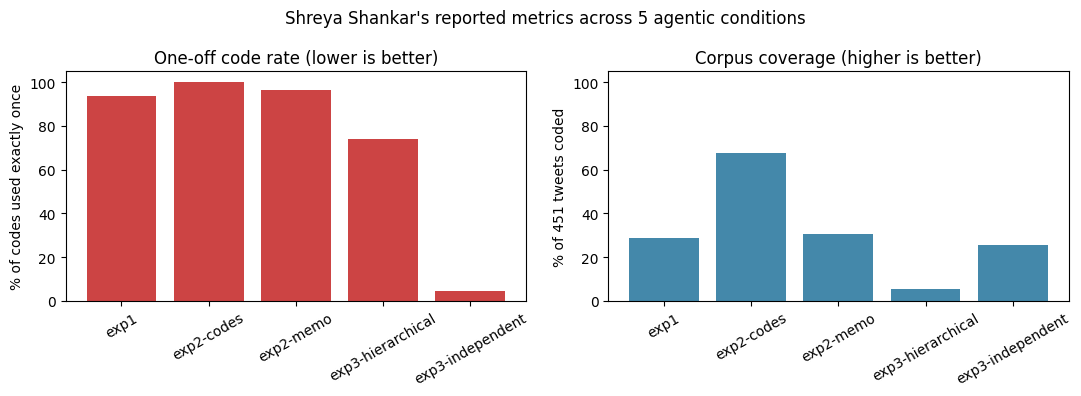

In [2]:
import matplotlib.pyplot as plt

# Numbers reported in Shreya Shankar, "Exploring Agent-Assisted Qualitative Analysis"
# (May 21, 2026), section "Agents paraphrase instead of analyzing" / Figure 3.
reported_one_off_rates = {
    "exp1": 93.8,
    "exp2-codes": 100.0,
    "exp2-memo": 96.5,
    "exp3-hierarchical": 74.2,
    "exp3-independent": 4.5,
}

# Coverage from Figure 4 of the same post.
reported_coverage = {
    "exp1": 28.6,
    "exp2-codes": 67.8,
    "exp2-memo": 30.6,
    "exp3-hierarchical": 5.5,
    "exp3-independent": 25.3,
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(
    reported_one_off_rates.keys(), reported_one_off_rates.values(), color="#c44"
)
axes[0].set_title("One-off code rate (lower is better)")
axes[0].set_ylabel("% of codes used exactly once")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(reported_coverage.keys(), reported_coverage.values(), color="#48a")
axes[1].set_title("Corpus coverage (higher is better)")
axes[1].set_ylabel("% of 451 tweets coded")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("Shreya Shankar's reported metrics across 5 agentic conditions")
fig.tight_layout()
plt.show()

Two things stand out in the charts:

- **`exp2-codes` has 100% one-off codes but the best coverage.** Per-tweet code review keeps the agent moving through the corpus, but doesn't produce a reusable vocabulary — because reviewing a code in isolation doesn't push you to merge it with earlier ones.
- **`exp3-independent` is the only condition with real code reuse (4.5%)** — and it got there by forcing two coder subagents to apply a *predefined* category list. Reuse came from constraint, not from the agent's own consolidation behaviour.

The takeaway aligns with Shreya's framing: **convergence has to be engineered**, not assumed to emerge from putting the codebook in context.

## 9. Data sources

Everything in this notebook traces back to a real source. The Python demo uses a clearly-labelled toy codebook; no fabricated experimental data is presented as Shreya's.

| Item | Source |
|---|---|
| Blog post (all narrative, quotes, findings) | Shreya Shankar, *Exploring Agent-Assisted Qualitative Analysis*, blog post, **May 21, 2026**, ~28 min read. Author page: Home / Papers / Blog / Google Scholar / Twitter / GitHub. © 2026 Shreya Shankar. Built with Astro. |
| Tweet corpus (n=451) referenced in the post | Replies to Sholto Douglas's tweet: *"When do you reach for other models instead of Claude? What can we do better?"* — scraped by Shreya for the experiments. Not redistributed in this notebook. |
| One-off code rates (`exp1` … `exp3-independent`) | Figure 3 of the blog post. |
| Corpus coverage percentages | Figure 4 of the blog post. |
| Quote: *"Opus 4.7 has a huge problem respecting user intent…"* | `@PromptedSpiral` tweet, cited in the post's "Agents paraphrase instead of analyzing" section. |
| Final per-condition reports (referenced, not reproduced) | Figure 2 of the blog post; full agent run traces in the post's linked interactive trace viewer. |
| Quote: *"Agents can do the mechanical parts of qualitative analysis fast, but they have no taste."* | Closing line of the post. |
| Toy `agent_like` / `human_like` codebooks (§8) | **Synthetic, written for this notebook** to illustrate the metric definition only. Not real coding data. |

**Notebook author note.** This notebook was written in `/Users/mhuang/Documents/GitHub/abook/notebooks/analysis/` on **2026-05-26** as a study companion to the post. Quotes and figures are attributable to Shreya Shankar; framing, code, and section structure are this notebook's restatement.